In [10]:
import pandas as pd
import optuna 
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error

import pickle

In [11]:
link = '/Users/maxkucher/bcs_ai/threat_model/threat_data.csv'
data = pd.read_csv(link)
data

,Unnamed: 0,class_score,distance_score,future_dist_score,action,direction_score,confidence,intent,threat
0,0,1.0,0.613639,0.632597,0.228065,1.0,0.572076,0.1,0.597933
1,1,0.8,0.784872,0.875178,0.839524,1.0,0.619044,0.3,0.781948
2,2,0.7,0.698952,0.743294,0.798072,1.0,0.625434,1.0,0.893746
3,3,1.0,0.640992,0.642332,0.132402,0.3,0.870379,0.1,0.557315
4,4,0.8,0.807733,0.777699,0.661243,0.7,0.772051,0.3,0.665039
...,...,...,...,...,...,...,...,...,...
99995,99995,0.8,0.756411,0.756640,0.485782,1.0,0.639526,0.3,0.750454
99996,99996,0.8,0.765817,0.797266,0.402158,0.7,0.731030,0.3,0.625890
99997,99997,0.7,0.723765,0.743735,0.220021,0.3,0.461820,0.3,0.583581
99998,99998,1.0,0.816114,0.918378,0.105402,1.0,0.763687,0.3,0.726183


In [12]:
data = data.drop('Unnamed: 0', axis='columns')
data

,class_score,distance_score,future_dist_score,action,direction_score,confidence,intent,threat
0,1.0,0.613639,0.632597,0.228065,1.0,0.572076,0.1,0.597933
1,0.8,0.784872,0.875178,0.839524,1.0,0.619044,0.3,0.781948
2,0.7,0.698952,0.743294,0.798072,1.0,0.625434,1.0,0.893746
3,1.0,0.640992,0.642332,0.132402,0.3,0.870379,0.1,0.557315
4,0.8,0.807733,0.777699,0.661243,0.7,0.772051,0.3,0.665039
...,...,...,...,...,...,...,...,...
99995,0.8,0.756411,0.756640,0.485782,1.0,0.639526,0.3,0.750454
99996,0.8,0.765817,0.797266,0.402158,0.7,0.731030,0.3,0.625890
99997,0.7,0.723765,0.743735,0.220021,0.3,0.461820,0.3,0.583581
99998,1.0,0.816114,0.918378,0.105402,1.0,0.763687,0.3,0.726183


In [13]:
x = data.drop('threat', axis='columns')
y = data['threat']

In [14]:
# x = x.astype(float)
# y = y.astype(float)

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [16]:
def objective(trial):
    model = RandomForestRegressor(
        n_estimators=trial.suggest_int('n_estimators', 50, 300), 
        max_depth=trial.suggest_int('max_depth', 8, 32), 
        min_samples_split=trial.suggest_int('min_samples_split', 2, 20), 
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 20), 
        max_features=trial.suggest_categorical('max_features', ["sqrt", "log2", None]), 
        n_jobs=-1,
        random_state=42)
    
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)
    
    score = mean_absolute_error(y_test, y_pred)

    return score 
    

In [17]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=35)

[I 2026-04-10 20:32:30,893] A new study created in memory with name: no-name-a3965a04-2200-42a4-954a-c6eb80d65db1
[I 2026-04-10 20:32:32,386] Trial 0 finished with value: 0.025063257325953357 and parameters: {'n_estimators': 122, 'max_depth': 26, 'min_samples_split': 10, 'min_samples_leaf': 12, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.025063257325953357.
[I 2026-04-10 20:32:44,088] Trial 1 finished with value: 0.025045319910524277 and parameters: {'n_estimators': 280, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 13, 'max_features': None}. Best is trial 1 with value: 0.025045319910524277.
[I 2026-04-10 20:32:48,054] Trial 2 finished with value: 0.024760486127286162 and parameters: {'n_estimators': 291, 'max_depth': 27, 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.024760486127286162.
[I 2026-04-10 20:32:49,371] Trial 3 finished with value: 0.024841935583923624 and parameters: {'n_estimators': 93, 'max

In [18]:
print(x.dtypes)
print(x.head())

class_score          float64
distance_score       float64
future_dist_score    float64
action               float64
direction_score      float64
confidence           float64
intent               float64
dtype: object
   class_score  distance_score  future_dist_score    action  direction_score  \
0          1.0        0.613639           0.632597  0.228065              1.0   
1          0.8        0.784872           0.875178  0.839524              1.0   
2          0.7        0.698952           0.743294  0.798072              1.0   
3          1.0        0.640992           0.642332  0.132402              0.3   
4          0.8        0.807733           0.777699  0.661243              0.7   

   confidence  intent  
0    0.572076     0.1  
1    0.619044     0.3  
2    0.625434     1.0  
3    0.870379     0.1  
4    0.772051     0.3  


In [19]:
from sklearn import set_config
set_config(display="text")

best_model = RandomForestRegressor(**study.best_params)
best_model.fit(x_train, y_train)

RandomForestRegressor(max_depth=24, max_features='sqrt', min_samples_split=17,
                      n_estimators=263)

In [20]:
y_pred = best_model.predict(x_test)

rmse = root_mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse} | MSE: {mse} | MAE: {mae}")

RMSE: 0.030990214773573905 | MSE: 0.0009603934117122383 | MAE: 0.024735102365813718


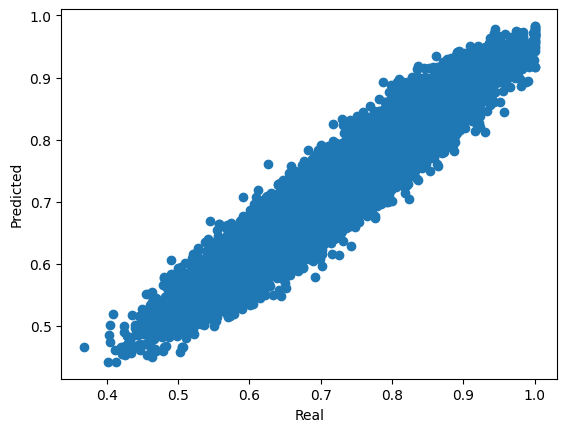

In [21]:
plt.scatter(y_test, y_pred)
plt.xlabel("Real")
plt.ylabel("Predicted")
plt.show()

In [22]:
with open("threat_model.pkl", "wb") as f:
    pickle.dump(best_model, f)